# 03 - NLSE solver validation (SW-P*)
split-step vs analytics. mostly a sanity check on the propagation code.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
# quick path hack so the repo modules import from notebooks/


In [2]:
#MD ## dispersive broadening (SW-P1)

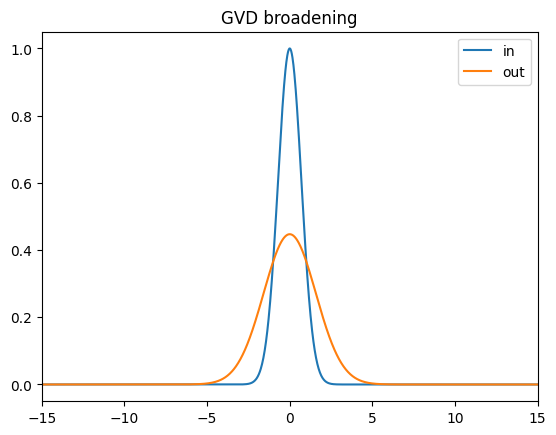

rms out 1.581 expected 1.581


In [3]:
from fiber_propagation import (gaussian_pulse, sech_pulse, split_step_fourier,
    dispersion_length, fundamental_soliton_power, energy, rms_width)
t = np.linspace(-40,40,4096)
T0, b2 = 1.0, -1.0
A0 = gaussian_pulse(t, T0=T0)
LD = dispersion_length(T0,b2); z = 2*LD
A = split_step_fourier(A0,t,z,2000,beta2=b2)
plt.plot(t, np.abs(A0)**2, label="in"); plt.plot(t, np.abs(A)**2, label="out")
plt.xlim(-15,15); plt.legend(); plt.title("GVD broadening"); plt.show()
exp = rms_width(A0,t)*np.sqrt(1+(z/LD)**2)
print("rms out", round(rms_width(A,t),3), "expected", round(exp,3))
assert abs(rms_width(A,t)-exp)/exp < 0.02   # broadens by sqrt(1+(z/LD)^2), nice

In [4]:
#MD ## fundamental soliton holds shape (SW-P2)

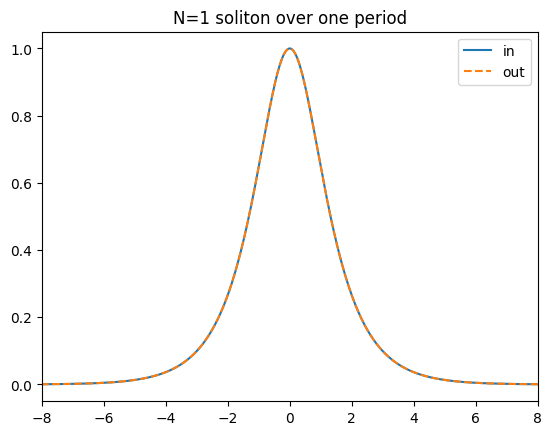

peak drift 4.690032029408542e-09


In [5]:
P0 = fundamental_soliton_power(T0,b2,1.0)
A0 = sech_pulse(t, T0=T0, P0=P0)
z0 = (np.pi/2)*LD
A = split_step_fourier(A0,t,z0,4000,beta2=b2,gamma=1.0)
plt.plot(t, np.abs(A0), label="in"); plt.plot(t, np.abs(A),'--', label="out")
plt.xlim(-8,8); plt.legend(); plt.title("N=1 soliton over one period"); plt.show()
print("peak drift", abs(np.max(np.abs(A))-np.max(np.abs(A0))))
# soliton barely moves, kinda cool

In [6]:
#MD ## energy conservation + loss (SW-P3, SW-P4)

In [7]:
A0 = gaussian_pulse(t, T0=1.0)
A = split_step_fourier(A0,t,5.0,1000,beta2=-1.0,gamma=1.0)
print("lossless energy ratio", energy(A,t)/energy(A0,t))   # ~1
al=0.2; Al = split_step_fourier(A0,t,3.0,1000,beta2=-1.0,alpha=al)
print("with loss", energy(Al,t)/energy(A0,t), "expected", np.exp(-al*3.0))
# decays as exp(-a z), good enough

lossless energy ratio 1.0000000000004996


with loss 0.5488116360943003 expected 0.5488116360940264
